In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler


In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Saave the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_numeric_std = StandardScaler().fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

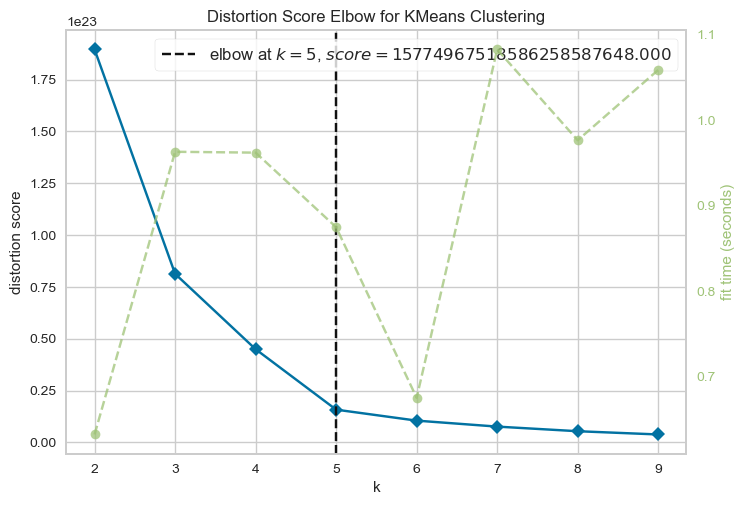

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glszm_SizeZoneNonUniformity_PET_b2
Correlation coefficient: 1.0072463768115953


1
Most correlated column: gldm_DependenceNonUniformityNormalized_d_1_CT_b20
Correlation coefficient: 1.0072463768115951


2
Most correlated column: first_order_90Percentile_PET
Correlation coefficient: 1.0072463768115951


3
Most correlated column: glszm_HighGrayLevelZoneEmphasis_PET_c04
Correlation coefficient: 1.0072463768115953


4
Most correlated column: glcm_MCC_d_1_CT_b20
Correlation coefficient: 1.0072463768115953




In [21]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,glszm_SizeZoneNonUniformity_PET_b2,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,first_order_90Percentile_PET,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,3.470588,0.055238,12.976912,20.909091,0.817715
1,1.250000,0.050688,5.631130,17.583333,0.773956
2,1.600000,0.048612,6.963644,13.000000,0.810414
3,1.000000,0.077182,2.937064,18.818182,0.710132
4,1.461538,0.073116,5.652872,17.481481,0.567600
...,...,...,...,...,...
134,1.000000,0.052052,8.774738,15.000000,0.790123
135,1.250000,0.039528,6.606596,16.050000,0.826556
136,3.580645,0.039913,12.128900,16.000000,0.697606
137,1.428571,0.040037,7.277164,14.125000,0.753842


In [25]:
X_new_std

,glszm_SizeZoneNonUniformity_PET_b2,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,first_order_90Percentile_PET,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,0.295403,0.771033,0.644250,1.588680,0.482340
1,-0.559920,0.349452,-0.947354,0.719022,-0.140484
2,-0.425107,0.157028,-0.658639,-0.479481,0.378424
3,-0.656214,2.804650,-1.531075,1.041925,-1.048871
4,-0.478440,2.427799,-0.942643,0.692389,-3.077512
...,...,...,...,...,...
134,-0.656214,0.475848,-0.266231,0.043502,0.089627
135,-0.559920,-0.684808,-0.736001,0.318068,0.608165
136,0.337795,-0.649065,0.460512,0.304994,-1.227159
137,-0.491138,-0.637641,-0.590709,-0.185303,-0.426754


In [26]:
MAASTRO_new

,glszm_SizeZoneNonUniformity_PET_b2,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,first_order_90Percentile_PET,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,3.333333,0.039893,14.076383,10.218750,0.734071
1,1.153846,0.044395,7.077812,12.055556,0.828113
2,1.444444,0.040159,11.123887,19.312500,0.778776
3,1.000000,0.061403,7.374829,15.611111,0.864230
4,1.153846,0.039451,8.358805,10.107143,0.842091
...,...,...,...,...,...
94,4.428571,0.040698,28.833381,16.684211,0.813111
95,1.105263,0.051691,11.134466,19.363636,0.857525
96,1.000000,0.039945,7.233497,10.333333,0.796506
97,2.760000,0.047941,11.935536,13.941176,0.836464


In [27]:
MAASTRO_new_std

,glszm_SizeZoneNonUniformity_PET_b2,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,first_order_90Percentile_PET,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,0.242536,-0.651003,0.882471,-1.206755,-0.708161
1,-0.596956,-0.233801,-0.633903,-0.726446,0.630334
2,-0.485024,-0.626272,0.242757,1.171185,-0.071881
3,-0.656214,1.342407,-0.569548,0.203303,1.144373
4,-0.596956,-0.691949,-0.356351,-1.235939,0.829272
...,...,...,...,...,...
94,0.664398,-0.576406,4.079857,0.483909,0.416811
95,-0.615669,0.442402,0.245049,1.184557,1.048942
96,-0.656214,-0.646098,-0.600170,-1.176792,0.180468
97,0.021700,0.094875,0.418616,-0.233371,0.749184


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 17:18:00,849] A new study created in memory with name: no-name-0ab29120-2cac-4306-9e27-97b63a246e14


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5267857142857143


[I 2024-04-19 17:18:01,577] A new study created in memory with name: no-name-10569d9e-3edb-4e69-ad5a-b2c027d2462c


Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6666666666666666
[I 2024-04-19 17:18:01,564] Trial 0 finished with value: 0.5450231358366131 and parameters: {}. Best is trial 0 with value: 0.5450231358366131.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5450231358366131], datetime_start=datetime.datetime(2024, 4, 19, 17, 18, 1, 19855), datetime_complete=datetime.datetime(2024, 4, 19, 17, 18, 1, 563511), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5450231358366131


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26743406350742227
Fold 2 IBS: 0.23242999680243095
Fold 3 IBS: 0.20367595815504286
Fold 4 IBS: 0.2349843485440125
Fold 5 IBS: 0.20514543430359342
[I 2024-04-19 17:18:02,375] Trial 0 finished with value: 0.2287339602625004 and parameters: {}. Best is trial 0 with value: 0.2287339602625004.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2287339602625004], datetime_start=datetime.datetime(2024, 4, 19, 17, 18, 1, 608341), datetime_complete=datetime.datetime(2024, 4, 19, 17, 18, 2, 375510), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2287339602625004


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.545
train_ibs:  0.229


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.512
IBS score: 0.229


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:18:02,832] A new study created in memory with name: no-name-bed614c3-4338-4b2d-bf2a-458e40d57c98


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5151515151515151
Fold 2 C-index: 0.26339285714285715
Fold 3 C-index: 0.47794117647058826


[I 2024-04-19 17:18:03,181] A new study created in memory with name: no-name-6f72452e-403c-4f61-87f9-b8c99c6b0dcd


Fold 4 C-index: 0.4936708860759494
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 17:18:03,162] Trial 0 finished with value: 0.4674021789869613 and parameters: {}. Best is trial 0 with value: 0.4674021789869613.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.4674021789869613], datetime_start=datetime.datetime(2024, 4, 19, 17, 18, 2, 873438), datetime_complete=datetime.datetime(2024, 4, 19, 17, 18, 3, 162444), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.4674021789869613


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652555810814
Fold 2 IBS: 0.22157792043310223
Fold 3 IBS: 0.20453594707363335
Fold 4 IBS: 0.22473804194106234
Fold 5 IBS: 0.21812431081055106
[I 2024-04-19 17:18:03,772] Trial 0 finished with value: 0.21659054916329143 and parameters: {}. Best is trial 0 with value: 0.21659054916329143.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054916329143], datetime_start=datetime.datetime(2024, 4, 19, 17, 18, 3, 218019), datetime_complete=datetime.datetime(2024, 4, 19, 17, 18, 3, 772451), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054916329143


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.467
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.487


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:18:04,128] A new study created in memory with name: no-name-17a7c680-81a4-4195-a0a0-39c7eef843c4


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5245098039215687


[I 2024-04-19 17:18:04,999] A new study created in memory with name: no-name-f2c15eb3-a585-4894-8e27-8ffdd2a54d6c


Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:04,977] Trial 0 finished with value: 0.5329040980806657 and parameters: {}. Best is trial 0 with value: 0.5329040980806657.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5329040980806657], datetime_start=datetime.datetime(2024, 4, 19, 17, 18, 4, 209224), datetime_complete=datetime.datetime(2024, 4, 19, 17, 18, 4, 976701), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5329040980806657


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26626342109875306
Fold 2 IBS: 0.2319743346058228
Fold 3 IBS: 0.20383267414621883
Fold 4 IBS: 0.23375020085139114
Fold 5 IBS: 0.21385244576801296
[I 2024-04-19 17:18:06,404] Trial 0 finished with value: 0.22993461529403975 and parameters: {}. Best is trial 0 with value: 0.22993461529403975.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22993461529403975], datetime_start=datetime.datetime(2024, 4, 19, 17, 18, 5, 84175), datetime_complete=datetime.datetime(2024, 4, 19, 17, 18, 6, 404313), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22993461529403975


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.533
train_ibs:  0.23


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.511


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:18:07,074] A new study created in memory with name: no-name-2e00c3f9-22d3-4694-ae1e-dba4dfb1d264


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6009389671361502
[I 2024-04-19 17:18:07,840] Trial 0 finished with value: 0.5309847387876527 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5309847387876527.
Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:08,663] Trial 1 finished with value: 0.531923705923803 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.531923705923803.
Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.5021097046413502
Fold 5 C-index: 0.6009389671361502
[I 2024-04-19 17:18:09,235] Trial 2 finished with value: 0.5242336839353321 and parameters: {'l1_ratio': 0.22692876841884668}

Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:25,218] Trial 23 finished with value: 0.5329040980806657 and parameters: {'l1_ratio': 0.8898693182098678}. Best is trial 6 with value: 0.5329040980806657.
Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5245098039215687
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:25,962] Trial 24 finished with value: 0.5329040980806657 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.5329040980806657.
Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5245098039215687
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:26,658] Trial 25 finished with value: 0.5329040980806657 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.5329040980806657.
Fold 1 C-index: 0.5411255411255411
Fold 2 C-index: 0.22321428571428573
Fold 3 C-index: 0

Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5245098039215687
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:44,314] Trial 47 finished with value: 0.5329040980806657 and parameters: {'l1_ratio': 0.9991045282580079}. Best is trial 6 with value: 0.5329040980806657.
Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5245098039215687
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:45,187] Trial 48 finished with value: 0.5329040980806657 and parameters: {'l1_ratio': 0.8619031648167028}. Best is trial 6 with value: 0.5329040980806657.
Fold 1 C-index: 0.47619047619047616
Fold 2 C-index: 0.5223214285714286
Fold 3 C-index: 0.5245098039215687
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 17:18:46,390] Trial 49 finished with value: 0.5329040980806657 and parameters: {'l1_ratio': 0.92078742017108

...

Fold 1 IBS: 0.2661576950006452
Fold 2 IBS: 0.23196921637536594
Fold 3 IBS: 0.2038069668012126
Fold 4 IBS: 0.23367129240514378
Fold 5 IBS: 0.2140349621389445
[I 2024-04-19 17:19:28,011] Trial 0 finished with value: 0.22992802654426242 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22992802654426242.
Fold 1 IBS: 0.26607166892538875
Fold 2 IBS: 0.2319441244936186
Fold 3 IBS: 0.20372989115272752
Fold 4 IBS: 0.23371171097804233
Fold 5 IBS: 0.21471495400113905
[I 2024-04-19 17:19:29,027] Trial 1 finished with value: 0.23003446991018323 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.22992802654426242.
Fold 1 IBS: 0.2660419419704605
Fold 2 IBS: 0.231928552337198
Fold 3 IBS: 0.2036992706466146
Fold 4 IBS: 0.22563934904403096
Fold 5 IBS: 0.21494682152915
[I 2024-04-19 17:19:29,962] Trial 2 finished with value: 0.22845118710549084 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.22845118710549084.
F

Fold 1 IBS: 0.21626870524171166
Fold 2 IBS: 0.22337909939131215
Fold 3 IBS: 0.2044937250451551
Fold 4 IBS: 0.22511399108339966
Fold 5 IBS: 0.2162291331988253
[I 2024-04-19 17:19:48,653] Trial 25 finished with value: 0.21709693079208076 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.216616207509405.
Fold 1 IBS: 0.2660874335366042
Fold 2 IBS: 0.23194237509470608
Fold 3 IBS: 0.20368650125415205
Fold 4 IBS: 0.22557578593401986
Fold 5 IBS: 0.21506426876332269
[I 2024-04-19 17:19:49,641] Trial 26 finished with value: 0.228471272916561 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 0.216616207509405.
Fold 1 IBS: 0.21580499822463994
Fold 2 IBS: 0.22305819412879427
Fold 3 IBS: 0.20448989973907006
Fold 4 IBS: 0.22503687610567671
Fold 5 IBS: 0.21650557972381132
[I 2024-04-19 17:19:50,185] Trial 27 finished with value: 0.21697910958439842 and parameters: {'l1_ratio': 0.056847137315710346}. Best is trial 13 with value: 0.2166162075

Fold 1 IBS: 0.26605448682948374
Fold 2 IBS: 0.22374063998813545
Fold 3 IBS: 0.20450050299797107
Fold 4 IBS: 0.22520622393828468
Fold 5 IBS: 0.21593871416458807
[I 2024-04-19 17:20:06,841] Trial 50 finished with value: 0.22708811358369257 and parameters: {'l1_ratio': 0.09451319327765746}. Best is trial 46 with value: 0.2165912237810257.
Fold 1 IBS: 0.21419046379456166
Fold 2 IBS: 0.22176833843294136
Fold 3 IBS: 0.20452275660771704
Fold 4 IBS: 0.2247708604541181
Fold 5 IBS: 0.21787296349320703
[I 2024-04-19 17:20:07,332] Trial 51 finished with value: 0.21662507655650903 and parameters: {'l1_ratio': 0.006012844952470507}. Best is trial 46 with value: 0.2165912237810257.
Fold 1 IBS: 0.21408001306189653
Fold 2 IBS: 0.2216705205265222
Fold 3 IBS: 0.20452920002959685
Fold 4 IBS: 0.22475375831413022
Fold 5 IBS: 0.21799982289668343
[I 2024-04-19 17:20:07,829] Trial 52 finished with value: 0.21660666296576586 and parameters: {'l1_ratio': 0.002886680027376676}. Best is trial 46 with value: 0.2165

Fold 5 IBS: 0.21803991786672103
[I 2024-04-19 17:20:20,683] Trial 74 finished with value: 0.21660128715436194 and parameters: {'l1_ratio': 0.001939745630995339}. Best is trial 63 with value: 0.21659114162210785.
Fold 1 IBS: 0.21521480669357423
Fold 2 IBS: 0.22261911667973974
Fold 3 IBS: 0.20449123640517952
Fold 4 IBS: 0.2249383234229692
Fold 5 IBS: 0.21691836696222094
[I 2024-04-19 17:20:21,097] Trial 75 finished with value: 0.21683637003273676 and parameters: {'l1_ratio': 0.03717982365573151}. Best is trial 63 with value: 0.21659114162210785.
Fold 1 IBS: 0.21621297022730893
Fold 2 IBS: 0.22334160763001862
Fold 3 IBS: 0.20449327951574342
Fold 4 IBS: 0.22510475598329288
Fold 5 IBS: 0.2162604638662765
[I 2024-04-19 17:20:21,668] Trial 76 finished with value: 0.21708261544452806 and parameters: {'l1_ratio': 0.0712774675720134}. Best is trial 63 with value: 0.21659114162210785.
Fold 1 IBS: 0.2660052187606798
Fold 2 IBS: 0.22407432173593345
Fold 3 IBS: 0.2036090822243406
Fold 4 IBS: 0.22529

Fold 1 IBS: 0.26605367839700433
Fold 2 IBS: 0.2318723202876984
Fold 3 IBS: 0.20361646300273256
Fold 4 IBS: 0.22532011480345238
Fold 5 IBS: 0.21562713625647878
[I 2024-04-19 17:20:36,987] Trial 99 finished with value: 0.22849794254947325 and parameters: {'l1_ratio': 0.12345871196024548}. Best is trial 63 with value: 0.21659114162210785.


* Best trial for IBS: 
 FrozenTrial(number=63, state=TrialState.COMPLETE, values=[0.21659114162210785], datetime_start=datetime.datetime(2024, 4, 19, 17, 20, 13, 582601), datetime_complete=datetime.datetime(2024, 4, 19, 17, 20, 14, 104935), params={'l1_ratio': 0.00010944776235348343}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=63, value=None)


* Best Score for IBS: 
 0.21659114162210785


In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.533
train_ibs:  0.217


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.511


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.00010944776235348343)

test_ibs:  0.221


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 17:20:37,467] A new study created in memory with name: no-name-908c552c-4fa1-441d-acc3-1850f59cf725


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4935064935064935
Fold 2 C-index: 0.4642857142857143
Fold 3 C-index: 0.5686274509803921
Fold 4 C-index: 0.5189873417721519
Fold 5 C-index: 0.5446009389671361
[I 2024-04-19 17:20:47,743] Trial 0 finished with value: 0.5180015879023776 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5180015879023776.
Fold 1 C-index: 0.48917748917748916
Fold 2 C-index: 0.40625
Fold 3 C-index: 0.5441176470588235
Fold 4 C-index: 0.48523206751054854
Fold 5 C-index: 0.5821596244131455
[I 2024-04-19 17:20:55,498] Trial 1 finished with value: 0.5013873656320014 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_feat

Fold 1 C-index: 0.48484848484848486
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6572769953051644
[I 2024-04-19 17:22:58,683] Trial 16 finished with value: 0.6283337936870076 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 88, 'oob_score': True, 'max_samples': 0.8360998471106429, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08633662845826989, 'warm_start': True}. Best is trial 16 with value: 0.6283337936870076.
Fold 1 C-index: 0.49783549783549785
Fold 2 C-index: 0.640625
Fold 3 C-index: 0.6470588235294118
Fold 4 C-index: 0.6434599156118144
Fold 5 C-index: 0.6431924882629108
[I 2024-04-19 17:23:00,341] Trial 17 finished with value: 0.6144343450479269 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 8, 'oob_score': True, 'max_samples': 0.8699768148803853, 'max_fea

Fold 1 C-index: 0.5064935064935064
Fold 2 C-index: 0.6875
Fold 3 C-index: 0.6911764705882353
Fold 4 C-index: 0.6751054852320675
Fold 5 C-index: 0.7323943661971831
[I 2024-04-19 17:23:31,830] Trial 31 finished with value: 0.6585339657021985 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 10, 'max_depth': 4, 'n_estimators': 156, 'oob_score': True, 'max_samples': 0.8095504112188036, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.13817630149223978, 'warm_start': True}. Best is trial 31 with value: 0.6585339657021985.
Fold 1 C-index: 0.5021645021645021
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.6708860759493671
Fold 5 C-index: 0.7511737089201878
[I 2024-04-19 17:23:37,469] Trial 32 finished with value: 0.6624534008241783 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 10, 'max_depth': 4, 'n_estimators': 161, 'oob_score': True, 'max_samples': 0.7931538648906105, 'max_featu

...

Fold 1 IBS: 0.22068320462830318
Fold 2 IBS: 0.21894435290731515
Fold 3 IBS: 0.20393536916489555
Fold 4 IBS: 0.22466418075081848
Fold 5 IBS: 0.21553175602101815
[I 2024-04-19 17:33:07,416] Trial 32 finished with value: 0.2167517726944701 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 3, 'n_estimators': 114, 'oob_score': True, 'max_samples': 0.4637050738097666, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.17862321975818124}. Best is trial 24 with value: 0.2117300501780912.
Fold 1 IBS: 0.21392740783428504
Fold 2 IBS: 0.22147537334686046
Fold 3 IBS: 0.20461062669468671
Fold 4 IBS: 0.2249997008591599
Fold 5 IBS: 0.21842754870867
[I 2024-04-19 17:33:10,919] Trial 33 finished with value: 0.21668813148873242 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 5, 'n_estimators': 70, 'oob_score': True, 'max_samples': 0.3433985337551526, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.22541094675289033
Fold 2 IBS: 0.22304721501663563
Fold 3 IBS: 0.20353660838637322
Fold 4 IBS: 0.22653360737192485
Fold 5 IBS: 0.21164512059812235
[I 2024-04-19 17:34:51,386] Trial 48 finished with value: 0.21803469962518926 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 17, 'max_depth': 4, 'n_estimators': 252, 'oob_score': True, 'max_samples': 0.5606440507914384, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.12868834187870568}. Best is trial 24 with value: 0.2117300501780912.
Fold 1 IBS: 0.2140694278537375
Fold 2 IBS: 0.22317579874477506
Fold 3 IBS: 0.2034583893275885
Fold 4 IBS: 0.22322228294207358
Fold 5 IBS: 0.21554362548706898
[I 2024-04-19 17:34:53,239] Trial 49 finished with value: 0.21589390487104873 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 6, 'n_estimators': 31, 'oob_score': True, 'max_samples': 0.4308254687971994, 'max_features': 'log2', 'min_weight_fraction_l

Fold 1 IBS: 0.21395684580705032
Fold 2 IBS: 0.22086571792159726
Fold 3 IBS: 0.20507697354699692
Fold 4 IBS: 0.22467266136309472
Fold 5 IBS: 0.21810331117088386
[I 2024-04-19 17:35:53,332] Trial 64 finished with value: 0.2165351019619246 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 9, 'min_samples_leaf': 17, 'max_depth': 3, 'n_estimators': 158, 'oob_score': True, 'max_samples': 0.26967029716304014, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.1093901859794816}. Best is trial 24 with value: 0.2117300501780912.
Fold 1 IBS: 0.2147210769083821
Fold 2 IBS: 0.2208281833765489
Fold 3 IBS: 0.20387704687737312
Fold 4 IBS: 0.2250561114401426
Fold 5 IBS: 0.21646467575170217
[I 2024-04-19 17:36:03,106] Trial 65 finished with value: 0.21618941887082976 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 225, 'oob_score': True, 'max_samples': 0.39967081912423197, 'max_features': 'sqrt', 'min_weight_fraction_leaf

Fold 1 IBS: 0.21914607869260122
Fold 2 IBS: 0.22146828971326593
Fold 3 IBS: 0.20329898520127004
Fold 4 IBS: 0.2258596571781877
Fold 5 IBS: 0.2149539622634001
[I 2024-04-19 17:37:36,487] Trial 80 finished with value: 0.216945394609745 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 19, 'min_samples_leaf': 18, 'max_depth': 3, 'n_estimators': 169, 'oob_score': True, 'max_samples': 0.47371879450874355, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.08741388758927555}. Best is trial 24 with value: 0.2117300501780912.
Fold 1 IBS: 0.21673069005463627
Fold 2 IBS: 0.22232702663718523
Fold 3 IBS: 0.20258109094233
Fold 4 IBS: 0.22483571092812343
Fold 5 IBS: 0.21503339588720258
[I 2024-04-19 17:37:43,740] Trial 81 finished with value: 0.21630158288989548 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 18, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 162, 'oob_score': True, 'max_samples': 0.4357509839660105, 'max_features': 'sqrt', 'min_weight_fraction_leaf':

Fold 1 IBS: 0.22160331308733208
Fold 2 IBS: 0.2235369426300126
Fold 3 IBS: 0.20424732642706592
Fold 4 IBS: 0.22575132458517724
Fold 5 IBS: 0.21430298314442844
[I 2024-04-19 17:38:41,995] Trial 96 finished with value: 0.21788837797480326 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 11, 'min_samples_leaf': 19, 'max_depth': 6, 'n_estimators': 84, 'oob_score': False, 'max_samples': 0.5972550179693354, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.021667129505974683}. Best is trial 24 with value: 0.2117300501780912.
Fold 1 IBS: 0.21399151037099556
Fold 2 IBS: 0.22157334466240483
Fold 3 IBS: 0.204454022524685
Fold 4 IBS: 0.22484717782508537
Fold 5 IBS: 0.21790277626552898
[I 2024-04-19 17:38:44,915] Trial 97 finished with value: 0.21655376632973994 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 19, 'max_depth': 5, 'n_estimators': 62, 'oob_score': False, 'max_samples': 0.5308879003036967, 'max_features': 'sqrt', 'min_weight_fraction_

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.811
train_ibs:  0.212


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_leaf_nodes=12,
                     max_samples=0.9288919252136055, min_samples_leaf=2,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.038611703622446016,
                     n_estimators=270, random_state=123, warm_start=True)

test_cindex:  0.56


RandomSurvivalForest(max_depth=3, max_leaf_nodes=18,
                     max_samples=0.5009696342973148, min_samples_leaf=18,
                     min_weight_fraction_leaf=0.23269542560982653,
                     n_estimators=2, oob_score=True, random_state=123)

test_ibs:  0.213


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:38:49,813] A new study created in memory with name: no-name-39af2385-4ffa-49f2-85fc-ea2ab3dbea45


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5151515151515151
Fold 2 C-index: 0.6785714285714286
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.6075949367088608
Fold 5 C-index: 0.647887323943662
[I 2024-04-19 17:38:53,063] Trial 0 finished with value: 0.6143508447966619 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6143508447966619.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 17:39:00,517] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 3 C-index: 0.5931372549019608
Fold 4 C-index: 0.5864978902953587
Fold 5 C-index: 0.596244131455399
[I 2024-04-19 17:40:25,660] Trial 15 finished with value: 0.5965449029495914 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6311440559465006.
Fold 1 C-index: 0.49783549783549785
Fold 2 C-index: 0.6316964285714286
Fold 3 C-index: 0.5808823529411765
Fold 4 C-index: 0.5632911392405063
Fold 5 C-index: 0.596244131455399
[I 2024-04-19 17:40:30,264] Trial 16 finished with value: 0.5739899100088016 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_

Fold 1 C-index: 0.5238095238095238
Fold 2 C-index: 0.6875
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.6751054852320675
Fold 5 C-index: 0.7464788732394366
[I 2024-04-19 17:41:35,989] Trial 30 finished with value: 0.6628532862601271 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.07504341894083728}. Best is trial 30 with value: 0.6628532862601271.
Fold 1 C-index: 0.48917748917748916
Fold 2 C-index: 0.75
Fold 3 C-index: 0.7843137254901961
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.8685446009389671
[I 2024-04-19 17:41:38,889] Trial 31 finished with value: 0.7286181335854656 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 344, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples'

...

Fold 1 IBS: 0.2139249466311429
Fold 2 IBS: 0.2213636760596031
Fold 3 IBS: 0.204024823769854
Fold 4 IBS: 0.22545491022729527
Fold 5 IBS: 0.21878273513910684
[I 2024-04-19 19:01:58,322] Trial 30 finished with value: 0.2167102183654004 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 6, 'min_samples_leaf': 18, 'max_depth': 4, 'n_estimators': 42, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.23596047192138714, 'min_weight_fraction_leaf': 0.20241101766143602}. Best is trial 8 with value: 0.21622129571945042.
Fold 1 IBS: 0.21396701567390541
Fold 2 IBS: 0.22033846658943976
Fold 3 IBS: 0.20474883610145098
Fold 4 IBS: 0.2246640606997593
Fold 5 IBS: 0.21754299647799943
[I 2024-04-19 19:02:02,417] Trial 31 finished with value: 0.21625227510851097 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 6, 'min_samples_leaf': 8, 'max_depth': 20, 'n_estimators': 90, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.15960918

Fold 1 IBS: 0.21687296276525725
Fold 2 IBS: 0.2213361421610518
Fold 3 IBS: 0.20391418445155507
Fold 4 IBS: 0.22517176921151147
Fold 5 IBS: 0.2175453129976242
[I 2024-04-19 19:03:36,748] Trial 45 finished with value: 0.21696807431739998 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 3, 'min_samples_leaf': 3, 'max_depth': 17, 'n_estimators': 279, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.49900423273335853, 'min_weight_fraction_leaf': 0.008746603027940253}. Best is trial 43 with value: 0.21597491503488508.
Fold 1 IBS: 0.21620912218152002
Fold 2 IBS: 0.218285669846465
Fold 3 IBS: 0.2040027231539407
Fold 4 IBS: 0.22377040766804024
Fold 5 IBS: 0.2174887831843966
[I 2024-04-19 19:03:43,920] Trial 46 finished with value: 0.21595134120687248 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 160, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.262

Fold 1 IBS: 0.2153721883279879
Fold 2 IBS: 0.2186775180828221
Fold 3 IBS: 0.20394586882792412
Fold 4 IBS: 0.22400963678304894
Fold 5 IBS: 0.21656189694725853
[I 2024-04-19 19:06:13,246] Trial 60 finished with value: 0.2157134217938083 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 5, 'max_depth': 13, 'n_estimators': 257, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.21436178818774482, 'min_weight_fraction_leaf': 0.004797686298935941}. Best is trial 60 with value: 0.2157134217938083.
Fold 1 IBS: 0.21480931946071619
Fold 2 IBS: 0.21905392103343874
Fold 3 IBS: 0.20406172408273765
Fold 4 IBS: 0.22453428522954424
Fold 5 IBS: 0.21672334671772928
[I 2024-04-19 19:06:24,664] Trial 61 finished with value: 0.2158365193048332 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 5, 'max_depth': 13, 'n_estimators': 241, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.204724204

Fold 1 IBS: 0.21398962754496417
Fold 2 IBS: 0.22054029553696725
Fold 3 IBS: 0.20534606690439228
Fold 4 IBS: 0.2248841750367664
Fold 5 IBS: 0.21730496548976827
[I 2024-04-19 19:09:15,981] Trial 75 finished with value: 0.21641302610257168 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 294, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.1591822592777309, 'min_weight_fraction_leaf': 0.00036924718660358985}. Best is trial 73 with value: 0.21568374309736055.
Fold 1 IBS: 0.2154328008311495
Fold 2 IBS: 0.218905559094823
Fold 3 IBS: 0.20416264662638373
Fold 4 IBS: 0.22396929025244708
Fold 5 IBS: 0.21690348508305798
[I 2024-04-19 19:09:23,434] Trial 76 finished with value: 0.21587475637757225 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 2, 'min_samples_leaf': 2, 'max_depth': 12, 'n_estimators': 237, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.19659264

Fold 1 IBS: 0.21391267899301336
Fold 2 IBS: 0.2204561818196674
Fold 3 IBS: 0.20505686114483024
Fold 4 IBS: 0.2253284979071704
Fold 5 IBS: 0.21713302123288006
[I 2024-04-19 19:11:28,066] Trial 90 finished with value: 0.2163774482195123 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 247, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.10829253546914484, 'min_weight_fraction_leaf': 0.049696537441028546}. Best is trial 73 with value: 0.21568374309736055.
Fold 1 IBS: 0.21496075651065694
Fold 2 IBS: 0.2190278387978306
Fold 3 IBS: 0.2043083595861157
Fold 4 IBS: 0.224249245004802
Fold 5 IBS: 0.2167280797414054
[I 2024-04-19 19:11:35,422] Trial 91 finished with value: 0.21585485592816217 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 222, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.21347260789

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.785
train_ibs:  0.216


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=13, max_features=None, max_leaf_nodes=17,
                   max_samples=0.9963596199653129, min_samples_leaf=2,
                   min_samples_split=7,
                   min_weight_fraction_leaf=0.007190494713887075,
                   n_estimators=65, random_state=123, warm_start=True)

C-index score: 0.596


ExtraSurvivalTrees(max_depth=10, max_features=1, max_leaf_nodes=2,
                   max_samples=0.19830128698412408, min_samples_leaf=2,
                   min_samples_split=18,
                   min_weight_fraction_leaf=0.0010396007321560076,
                   n_estimators=243, random_state=123, warm_start=True)

IBS: 0.221


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 19:12:51,173] A new study created in memory with name: no-name-0eb0c84b-7bf6-4ffc-9a38-b7d79f6bebe8


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:14:01,895] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:14:43,154] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:29:55,662] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5116734136117047.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:32:25,196] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:47:12,156] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5116734136117047.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:49:11,147] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560958
[I 2024-04-19 21:19:38,679] Trial 45 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.9423581992051376, 'learning_rate': 0.00870079568001468, 'dropout_rate': 0.9243730341297751, 'n_estimators': 331, 'criterion': 'squared_error', 'ccp_alpha': 7.04773521781731, 'min_weight_fraction_leaf': 0.19866658441469065, 'max_features': 0.1, 'min_impurity_decrease': 0.0017836769072294195, 'validation_fraction': 0.001686507347744337, 'min_samples_split': 7, 'max_leaf_nodes': 18, 'min_samples_leaf': 15, 'max_depth': 9}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 21:19:47,263] Trial 46 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7601306318519188, 'le

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-19 21:22:22,867] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9470345333627548, 'learning_rate': 0.020520871416557077, 'dropout_rate': 0.7546956719538825, 'n_estimators': 135, 'criterion': 'squared_error', 'ccp_alpha': 4.693918481824396, 'min_weight_fraction_leaf': 0.2487463324044564, 'max_features': 'log2', 'min_impurity_decrease': 9.495778915269051e-07, 'validation_fraction': 0.6682715637714014, 'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 8, 'max_depth': 11}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 21:22:32,637] Trial 57 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7915280524929411, 'learning_rate': 0.0121378377780

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 21:26:53,246] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8302433734032149, 'learning_rate': 0.006781737784397601, 'dropout_rate': 0.7453329148042112, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 4.017596992694904, 'min_weight_fraction_leaf': 0.2674964870273292, 'max_features': 0.1, 'min_impurity_decrease': 7.418918022704639e-05, 'validation_fraction': 0.8000570654422638, 'min_samples_split': 7, 'max_leaf_nodes': 9, 'min_samples_leaf': 17, 'max_depth': 1}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-19 21:27:07,448] Trial 68 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.9209957004165874, 'learning_rate': 0.01062423601337367, 'dropout_rate': 0.63834152440881

Fold 5 IBS: 0.21812431525609566
[I 2024-04-19 21:28:22,989] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5659512292187416, 'learning_rate': 0.042168567287789734, 'dropout_rate': 0.7696992583170289, 'n_estimators': 165, 'criterion': 'friedman_mse', 'ccp_alpha': 1.2314273637141515, 'min_weight_fraction_leaf': 0.30990905851584793, 'max_features': 1, 'min_impurity_decrease': 0.0006024009409869186, 'validation_fraction': 0.231271869721252, 'min_samples_split': 8, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 8}. Best is trial 14 with value: 0.21659054862241583.
Fold 1 IBS: 0.21402294131035365
Fold 2 IBS: 0.22151584254840867
Fold 3 IBS: 0.20434692506763266
Fold 4 IBS: 0.2247100387976614
Fold 5 IBS: 0.21809583940431526
[I 2024-04-19 21:28:24,267] Trial 79 finished with value: 0.2165383174256743 and parameters: {'subsample': 0.37577625196815084, 'learning_rate': 0.048880003857177695, 'dropout_rate': 0.5395271493420024, 'n_estimators': 30, 'crite

Fold 1 IBS: 0.2139768557876795
Fold 2 IBS: 0.22157960355889483
Fold 3 IBS: 0.2045336046290438
Fold 4 IBS: 0.22473690464576399
Fold 5 IBS: 0.21812028018214255
[I 2024-04-19 21:36:24,749] Trial 90 finished with value: 0.21658944976070496 and parameters: {'subsample': 0.36689688157769845, 'learning_rate': 0.010897609699570083, 'dropout_rate': 0.7383468242771098, 'n_estimators': 462, 'criterion': 'friedman_mse', 'ccp_alpha': 0.05264949617748739, 'min_weight_fraction_leaf': 0.20049409529446852, 'max_features': 0.1, 'min_impurity_decrease': 6.950906592906038e-06, 'validation_fraction': 0.3252116370634637, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 3}. Best is trial 79 with value: 0.2165383174256743.
Fold 1 IBS: 0.21397759462884078
Fold 2 IBS: 0.2215793992473554
Fold 3 IBS: 0.2045336047576834
Fold 4 IBS: 0.22473798756897126
Fold 5 IBS: 0.21812113183214524
[I 2024-04-19 21:36:59,695] Trial 91 finished with value: 0.2165899436069992 and parameters: {'subs

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.512
train_ibs:  0.217


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.515


GradientBoostingSurvivalAnalysis(ccp_alpha=0.03087187707929262,
                                 dropout_rate=0.5395271493420024,
                                 learning_rate=0.048880003857177695,
                                 max_features='log2', max_leaf_nodes=9,
                                 min_impurity_decrease=3.1261071962202034e-07,
                                 min_samples_leaf=18, min_samples_split=11,
                                 min_weight_fraction_leaf=0.21901875474116986,
                                 n_estimators=30, random_state=123,
                                 subsample=0.37577625196815084,
                                 validation_fraction=0.1671589307842662)

IBS: 0.221


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 21:40:40,448] A new study created in memory with name: no-name-9065e37b-f0f0-4923-a238-24da3bcc2147


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.23214285714285715
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.4936708860759494
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 21:40:42,165] Trial 0 finished with value: 0.47243924182746244 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.47243924182746244.
Fold 1 C-index: 0.5454545454545454
Fold 2 C-index: 0.23214285714285715
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.4978902953586498
Fold 5 C-index: 0.6056338028169014
[I 2024-04-19 21:40:51,667] Trial 1 finished with value: 0.4732831236840026 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.4732831236840026.
Fold 1 C-index: 0.5367965367965368
Fold 2 C-index: 0.22767857142857142
Fold 3 C-index: 0.47058823529411764

Fold 1 C-index: 0.5108225108225108
Fold 2 C-index: 0.4955357142857143
Fold 3 C-index: 0.5147058823529411
Fold 4 C-index: 0.5485232067510548
Fold 5 C-index: 0.5821596244131455
[I 2024-04-19 21:42:16,974] Trial 19 finished with value: 0.5303493877250733 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 11 with value: 0.5356308207897171.
Fold 1 C-index: 0.5151515151515151
Fold 2 C-index: 0.26785714285714285
Fold 3 C-index: 0.47549019607843135
Fold 4 C-index: 0.5358649789029536
Fold 5 C-index: 0.6009389671361502
[I 2024-04-19 21:42:25,744] Trial 20 finished with value: 0.47906056002523856 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 11 with value: 0.5356308207897171.
Fold 1 C-index: 0.5151515151515151
Fold 2 C-index: 0.3169642857142857
Fold 3 C-index: 0.5343137254901

Fold 5 C-index: 0.6197183098591549
[I 2024-04-19 21:43:04,606] Trial 37 finished with value: 0.5129725330139187 and parameters: {'subsample': 0.14978852037100462, 'dropout_rate': 0.14727671008894497, 'n_estimators': 162, 'learning_rate': 0.028741116607640116}. Best is trial 11 with value: 0.5356308207897171.
Fold 1 C-index: 0.5281385281385281
Fold 2 C-index: 0.32589285714285715
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5232067510548524
Fold 5 C-index: 0.6384976525821596
[I 2024-04-19 21:43:05,557] Trial 38 finished with value: 0.5002059813130912 and parameters: {'subsample': 0.23557094034920928, 'dropout_rate': 0.20842555076543395, 'n_estimators': 72, 'learning_rate': 0.036102497382507676}. Best is trial 11 with value: 0.5356308207897171.
Fold 1 C-index: 0.5281385281385281
Fold 2 C-index: 0.27232142857142855
Fold 3 C-index: 0.4852941176470588
Fold 4 C-index: 0.5147679324894515
Fold 5 C-index: 0.5915492957746479
[I 2024-04-19 21:43:08,191] Trial 39 finished with value: 0.4784

...

Fold 3 IBS: 0.21397425303393156
Fold 4 IBS: 0.23886548274073963
Fold 5 IBS: 0.203646854345869
[I 2024-04-19 21:46:30,662] Trial 19 finished with value: 0.23740498725299775 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.21662658780922395.
Fold 1 IBS: 0.23917865097799193
Fold 2 IBS: 0.23221286517119702
Fold 3 IBS: 0.20634814654683398
Fold 4 IBS: 0.22813366724228368
Fold 5 IBS: 0.21208996217935122
[I 2024-04-19 21:46:31,712] Trial 20 finished with value: 0.22359265842353157 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.21662658780922395.
Fold 1 IBS: 0.21409511449872326
Fold 2 IBS: 0.22167917387504318
Fold 3 IBS: 0.20453337359860024
Fold 4 IBS: 0.2247565661515621
Fold 5 IBS: 0.2180543524486933
[I 2024-04-19 21:46:32,079] Trial 21 finis

Fold 3 IBS: 0.23347836594180174
Fold 4 IBS: 0.2698014220626681
Fold 5 IBS: 0.1961522685896151
[I 2024-04-19 21:46:48,310] Trial 38 finished with value: 0.2669366991413419 and parameters: {'subsample': 0.5872963751371887, 'dropout_rate': 0.13272164755980653, 'n_estimators': 158, 'learning_rate': 0.0802388198308747}. Best is trial 22 with value: 0.21659546956016276.
Fold 1 IBS: 0.2383620870984525
Fold 2 IBS: 0.23162961466273807
Fold 3 IBS: 0.20618918982147857
Fold 4 IBS: 0.22823267879497353
Fold 5 IBS: 0.211318883992158
[I 2024-04-19 21:46:52,190] Trial 39 finished with value: 0.22314649087396013 and parameters: {'subsample': 0.9436047786916928, 'dropout_rate': 0.6881141432789704, 'n_estimators': 309, 'learning_rate': 0.005489826361343792}. Best is trial 22 with value: 0.21659546956016276.
Fold 1 IBS: 0.24192932147914747
Fold 2 IBS: 0.23259509179885404
Fold 3 IBS: 0.20614481730922046
Fold 4 IBS: 0.22851597351212782
Fold 5 IBS: 0.21199696077979877
[I 2024-04-19 21:46:52,896] Trial 40 fini

Fold 3 IBS: 0.2044189009540125
Fold 4 IBS: 0.22480616775218557
Fold 5 IBS: 0.21789401499737562
[I 2024-04-19 21:47:11,195] Trial 57 finished with value: 0.21663813235885904 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.7718188701053201, 'n_estimators': 14, 'learning_rate': 0.00946624250338223}. Best is trial 49 with value: 0.21659368642500532.
Fold 1 IBS: 0.33339432052724044
Fold 2 IBS: 0.3124091477523628
Fold 3 IBS: 0.25740191006136326
Fold 4 IBS: 0.27795644848067824
Fold 5 IBS: 0.1932933471448788
[I 2024-04-19 21:47:19,812] Trial 58 finished with value: 0.27489103479330473 and parameters: {'subsample': 0.865146645306422, 'dropout_rate': 0.8966649536246931, 'n_estimators': 498, 'learning_rate': 0.021601639136700584}. Best is trial 49 with value: 0.21659368642500532.
Fold 1 IBS: 0.2283260097181614
Fold 2 IBS: 0.2273246771332837
Fold 3 IBS: 0.20433190784750707
Fold 4 IBS: 0.22514080305895007
Fold 5 IBS: 0.2144636606323981
[I 2024-04-19 21:47:20,598] Trial 59 finis

Fold 4 IBS: 0.2249984491833549
Fold 5 IBS: 0.21712277694890364
[I 2024-04-19 21:47:34,954] Trial 76 finished with value: 0.21705750377760435 and parameters: {'subsample': 0.9763559949383024, 'dropout_rate': 0.7573867831114323, 'n_estimators': 66, 'learning_rate': 0.0034342443340050514}. Best is trial 49 with value: 0.21659368642500532.
Fold 1 IBS: 0.25413535626293976
Fold 2 IBS: 0.23709899919668748
Fold 3 IBS: 0.20841378522627288
Fold 4 IBS: 0.23100922824227876
Fold 5 IBS: 0.2080984948590749
[I 2024-04-19 21:47:39,893] Trial 77 finished with value: 0.22775117275745074 and parameters: {'subsample': 0.9547597689557937, 'dropout_rate': 0.7038071743828178, 'n_estimators': 337, 'learning_rate': 0.0075044044759892976}. Best is trial 49 with value: 0.21659368642500532.
Fold 1 IBS: 0.21701109723440196
Fold 2 IBS: 0.2237571373543988
Fold 3 IBS: 0.2045658057605933
Fold 4 IBS: 0.22520729935701495
Fold 5 IBS: 0.21674387662991806
[I 2024-04-19 21:47:40,337] Trial 78 finished with value: 0.217457043

Fold 1 IBS: 0.21613510779938164
Fold 2 IBS: 0.2230255374342201
Fold 3 IBS: 0.20454294837318274
Fold 4 IBS: 0.22506616597318416
Fold 5 IBS: 0.21693957260048602
[I 2024-04-19 21:47:49,282] Trial 96 finished with value: 0.21714186643609096 and parameters: {'subsample': 0.8295067803487776, 'dropout_rate': 0.9806455021652567, 'n_estimators': 23, 'learning_rate': 0.011711071287835006}. Best is trial 49 with value: 0.21659368642500532.
Fold 1 IBS: 0.2141531005398597
Fold 2 IBS: 0.2216847246074341
Fold 3 IBS: 0.2045312571608761
Fold 4 IBS: 0.22475437220660285
Fold 5 IBS: 0.21801681685166796
[I 2024-04-19 21:47:49,690] Trial 97 finished with value: 0.21662805427328813 and parameters: {'subsample': 0.3977113459423743, 'dropout_rate': 0.8946287469782958, 'n_estimators': 8, 'learning_rate': 0.0038189502939151576}. Best is trial 49 with value: 0.21659368642500532.
Fold 1 IBS: 0.214018599001136
Fold 2 IBS: 0.2216362890708874
Fold 3 IBS: 0.20453465058726805
Fold 4 IBS: 0.22474528112024014
Fold 5 IBS:

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.551
train_ibs:  0.217


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8480935187842629,
                                              learning_rate=0.05719708405750365,
                                              n_estimators=3, random_state=123,
                                              subsample=0.14784774802434106)

C-index score: 0.582


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8878567210334715,
                                              learning_rate=0.0016388078764098802,
                                              n_estimators=1, random_state=123,
                                              subsample=0.9935080009387302)

IBS: 0.221


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.811,1.0
ExtraSurvivalTrees,0.785,2.0
ComponentwiseGradientBoosting,0.551,3.0
CoxPH,0.545,4.0
CoxLasso,0.533,5.5
CoxElastic,0.533,5.5
GradientBoosting,0.512,7.0
CoxRidge,0.467,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.212,1.0
ExtraSurvivalTrees,0.216,2.0
CoxRidge,0.217,4.5
CoxElastic,0.217,4.5
GradientBoosting,0.217,4.5
ComponentwiseGradientBoosting,0.217,4.5
CoxPH,0.229,7.0
CoxLasso,0.230,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.596,1.0
ComponentwiseGradientBoosting,0.582,2.0
Randomsurvivalforest,0.560,3.0
GradientBoosting,0.515,4.0
CoxPH,0.512,5.0
CoxLasso,0.511,6.5
CoxElastic,0.511,6.5
CoxRidge,0.487,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.213,1.0
CoxRidge,0.221,4.0
CoxElastic,0.221,4.0
ExtraSurvivalTrees,0.221,4.0
GradientBoosting,0.221,4.0
ComponentwiseGradientBoosting,0.221,4.0
CoxPH,0.229,7.5
CoxLasso,0.229,7.5


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/standard/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_standard_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-19
